# Exploring a STAC time series with odc-stac

Loads several dates of a STAC collection into a single time-indexed `xarray` `Dataset` (via [odc-stac](https://odc-stac.readthedocs.io/)) instead of reading one item at a time, so you can plot a time series or animate a raster stack directly.

**Do we need MinIO config here?** Yes. Every STAC item's asset href is an `s3://bucket/key` URI pointing at this system's MinIO, not AWS S3 or a plain HTTPS URL (see [`docs/stac-access.md`](../docs/stac-access.md)). `odc-stac`/`stackstac` both read pixels through `rasterio`/GDAL under the hood, and GDAL only knows how to resolve `s3://` against real AWS by default — it needs to be told MinIO's endpoint via `AWS_S3_ENDPOINT`, or every read fails. Since the `geodata` bucket is public read, no real credentials are needed — `AWS_NO_SIGN_REQUEST=YES` is enough (see the config cell below).

In [1]:
!pip install pystac-client odc-stac rasterio matplotlib numpy

zsh:1: /Volumes/drive/ACMAD/e-safari/geomgr/venv_geo/bin/pip: bad interpreter: /Volumes/Projects/ACMAD/e-safari/geomgr/venv_geo/bin/python3: no such file or directory
  Using cached odc_stac-0.5.3-py3-none-any.whl.metadata (5.7 kB)
  Using cached odc_geo-0.5.3-py3-none-any.whl.metadata (5.3 kB)
  Using cached odc_loader-0.6.4-py3-none-any.whl.metadata (1.4 kB)
Using cached odc_stac-0.5.3-py3-none-any.whl (44 kB)
Using cached odc_geo-0.5.3-py3-none-any.whl (159 kB)
Using cached odc_loader-0.6.4-py3-none-any.whl (58 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.1 MB/s eta 0:00:00a 0:00:010m


In [2]:
import os
import matplotlib.pyplot as plt
from pystac_client import Client
import odc.stac

## Config

This notebook targets production only.

In [3]:
stac_url = "https://multi-hazard.acmad.org/stac"

# The geodata bucket has a public anonymous-read policy, so no MinIO credentials
# are needed — AWS_NO_SIGN_REQUEST tells GDAL to skip request signing entirely.
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["AWS_S3_ENDPOINT"] = "minio.acmad.org"
os.environ["AWS_HTTPS"] = "YES"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"

print("STAC URL:", stac_url)
print("S3 endpoint:", os.environ["AWS_S3_ENDPOINT"])

STAC URL: https://multi-hazard.acmad.org/stac
S3 endpoint: minio.acmad.org


## Search a date range

`5-day-cumulative-rainfall` is ingested daily — pull the last 10 available items.

In [4]:
collection = "5-day-cumulative-rainfall"

catalog = Client.open(stac_url)
search = catalog.search(collections=[collection], max_items=10)
items = sorted(search.items(), key=lambda it: it.datetime)
print(f"Found {len(items)} items")
for item in items:
    print(item.id, item.datetime)

Found 10 items
5-day-cumulative-rainfall_20260729 2026-07-29 00:00:00+00:00
5-day-cumulative-rainfall_20260730 2026-07-30 00:00:00+00:00
5-day-cumulative-rainfall_20260731 2026-07-31 00:00:00+00:00
5-day-cumulative-rainfall_20260801 2026-08-01 00:00:00+00:00
5-day-cumulative-rainfall_20260802 2026-08-02 00:00:00+00:00
5-day-cumulative-rainfall_20260804 2026-08-04 00:00:00+00:00
5-day-cumulative-rainfall_20260805 2026-08-05 00:00:00+00:00
5-day-cumulative-rainfall_20260806 2026-08-06 00:00:00+00:00
5-day-cumulative-rainfall_20260807 2026-08-07 00:00:00+00:00
5-day-cumulative-rainfall_20260808 2026-08-08 00:00:00+00:00


## Stack into a time-indexed Dataset

`odc.stac.load` normally infers CRS/resolution from the STAC items' `proj:*` extension fields, but these items don't carry that extension — pass `crs`/`resolution` explicitly (checked directly against one asset with `rasterio` beforehand: `EPSG:4326`, `0.125°`). `chunks={}` makes this dask-backed/lazy — nothing is actually read from MinIO until you `.compute()` or plot.

In [ ]:
ds = odc.stac.load(
    items,
    bands=["data"],
    crs="EPSG:4326",
    resolution=0.125,  # decimal degrees — CRS is geographic (EPSG:4326), not meters
    chunks={},
)
ds

## Nodata caveat

These COGs don't have a `nodata` value set on the GeoTIFF itself — out-of-domain pixels are filled with a large negative sentinel (`-9.99e8`) instead of being tagged as nodata, so `rasterio`/`odc-stac` can't mask them automatically. Mask it explicitly before computing any real statistic (a raw `.mean()` without this is meaningless — it'll be dominated by the sentinel).

In [6]:
rainfall = ds["data"].where(ds["data"] > -1e6)

## Explore: spatial-mean time series + latest snapshot map

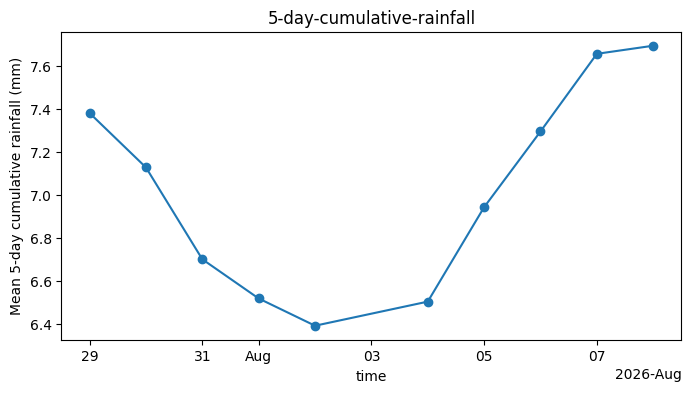

In [7]:
spatial_mean = rainfall.mean(dim=["latitude", "longitude"]).compute()

fig, ax = plt.subplots(figsize=(8, 4))
spatial_mean.plot(ax=ax, marker="o")
ax.set_ylabel("Mean 5-day cumulative rainfall (mm)")
ax.set_title(collection)
plt.show()

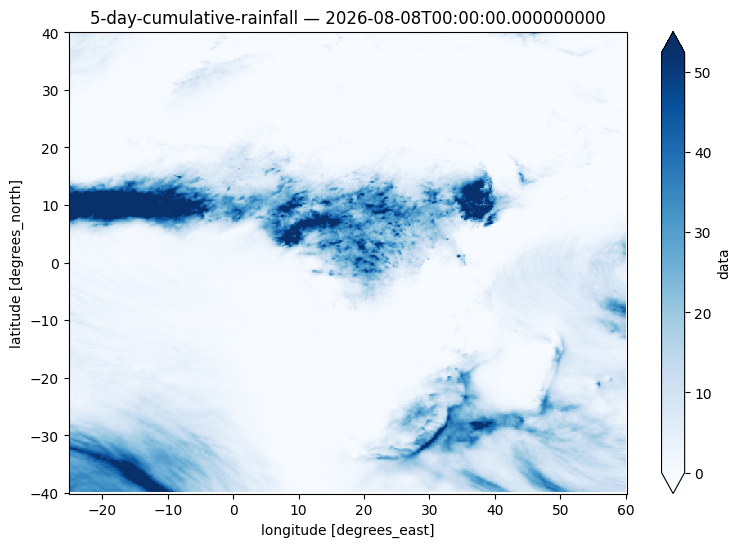

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
rainfall.isel(time=-1).plot(ax=ax, cmap="Blues", robust=True)
ax.set_title(f"{collection} — {rainfall.time.isel(time=-1).values}")
plt.show()

## Alternative: stackstac

`stackstac.stack(items, ...)` is a similar, lighter-weight library for the same job (`pip install stackstac`), also `rasterio`/GDAL-backed underneath — it needs the exact same `AWS_S3_ENDPOINT`/`AWS_NO_SIGN_REQUEST` config above, nothing extra. `odc-stac` is used here since it's the more actively maintained of the two.